<a href="https://colab.research.google.com/github/j019/Practical-Machine-Learning/blob/main/Day7/CaseStudy_Early_Wakeup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Case Study : Early Wakeup Health
- Dataset : https://www.kaggle.com/datasets/nalisha/early-wakeup-health-and-lifestyle-dataset

In [3]:
import pandas as pd
df = pd.read_csv('/content/early_wakeup_health_dataset.csv')

In [4]:
df.shape

(10000, 64)

In [5]:
df.isna().sum().sum()

np.int64(4662)

In [6]:
df.isna().sum()

,0
Person_ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
...,...
Health_Score,0
Fitness_Level,0
Healthy_Aging_Score,0
Wellness_Category,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  object 
 1   Age                             10000 non-null  int64  
 2   Gender                          10000 non-null  object 
 3   Height_cm                       10000 non-null  float64
 4   Weight_kg                       10000 non-null  float64
 5   BMI                             10000 non-null  float64
 6   Country                         10000 non-null  object 
 7   Occupation                      10000 non-null  object 
 8   Marital_Status                  10000 non-null  object 
 9   Wake_Up_Time                    10000 non-null  object 
 10  Sleep_Time                      10000 non-null  object 
 11  Sleep_Duration_Hours            10000 non-null  float64
 12  Sleep_Quality_Score             1

## drop columns --> personId, height, Weight, Gym_Member,Earlywaker



### Drop Target Columns -->
 - Obesity_risk, Hypertension, sleepdisorder, Cardiovascular,
 - HealthyAgeing, Wellness, Depression_risk_score, Depression_risk

### Target Columns-->
- Fitness_level --> Multi Class Classification task

- Country --> check distribution --> remove less occurence --> Done --> No need to remove

### -->
* Productivity_Score --> to be discussed


In [8]:
df['Country'].value_counts()

,count
Country,
USA,1468
India,1206
UK,798
Canada,763
Japan,667
Germany,623
Pakistan,598
Australia,574
Brazil,572


In [9]:
# Drop Columns(irrelevant & target Columns)
df.drop(columns=['Obesity_Risk',
'Hypertension_Risk',
'Diabetes_Risk',
'Cardiovascular_Risk',
'Sleep_Disorder_Risk',
'Health_Score',
'Healthy_Aging_Score',
'Wellness_Category',
'Early_Waker',
'Depression_Risk_Score',
'Gym_Member',
'Height_cm',
'Weight_kg',
'Person_ID'],inplace=True)



In [10]:
df.shape

(10000, 50)

## Convert Date Time to Category (Wake Up Time & Sleep Time)
### Preprocessing on Wake up Time & Sleep Time
#### Wake up Time --> Convert to categorical
- 4am - 6am --> Early Morning --> 0
- 6am - 8am --> Morning Time --> 1
- 8am - 10am --> Late --> 2
- 10am - 11am --> Very Late -->3

### Sleep Time --> Convert to categorical
- 6pm - 8pm --> Outlier --> 5
- 8pm - 10pm --> Early --> 0
- 10pm - 12am --> On-time --> 1
- 0am - 3am --> Late --> 2
- 3am - 7am --> Very Late --> 4




In [11]:
df['Wake_Up_Time'] = pd.to_datetime(df['Wake_Up_Time'])
df['Sleep_Time'] = pd.to_datetime(df['Sleep_Time'])

/tmp/ipykernel_6010/214474565.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Wake_Up_Time'] = pd.to_datetime(df['Wake_Up_Time'])
/tmp/ipykernel_6010/214474565.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Sleep_Time'] = pd.to_datetime(df['Sleep_Time'])


In [12]:
df['Wake_Up_Time'].head()

,Wake_Up_Time
0,2026-06-28 07:06:00
1,2026-06-28 05:17:00
2,2026-06-28 07:44:00
3,2026-06-28 10:07:00
4,2026-06-28 06:48:00


In [13]:
df['WT_cat'] = 0 #WakeUp_time -->categorical

In [14]:
df.loc[(df['Wake_Up_Time'] >= "2026-06-27 04:00:00") & (df['Wake_Up_Time'] < "2026-06-27 06:00:00"), "WT_cat" ] = 0
df.loc[(df['Wake_Up_Time'] >= "2026-06-27 06:00:00") & (df['Wake_Up_Time'] < "2026-06-27 08:00:00"), "WT_cat" ] = 1
df.loc[(df['Wake_Up_Time'] >= "2026-06-27 08:00:00") & (df['Wake_Up_Time'] < "2026-06-27 10:00:00"), "WT_cat" ] = 2
df.loc[(df['Wake_Up_Time'] >= "2026-06-27 10:00:00") & (df['Wake_Up_Time'] <= "2026-06-27 11:00:00"), "WT_cat" ] = 3

In [15]:
df['WT_cat'].unique()

array([0])

In [16]:
df['Sleep_Time'].head()

,Sleep_Time
0,2026-06-28 23:01:00
1,2026-06-28 00:45:00
2,2026-06-28 01:04:00
3,2026-06-28 03:56:00
4,2026-06-28 00:56:00


In [17]:
df['Sleep_Time'].sort_values()

,Sleep_Time
8046,2026-06-28 00:00:00
4212,2026-06-28 00:00:00
9375,2026-06-28 00:00:00
9314,2026-06-28 00:00:00
6716,2026-06-28 00:00:00
...,...
931,2026-06-28 23:59:00
4778,2026-06-28 23:59:00
9341,2026-06-28 23:59:00
2556,2026-06-28 23:59:00


In [18]:
df['ST_cat'] = 0

In [19]:
df.loc[(df['Sleep_Time'] >= "2026-06-27 20:00:00") & (df['Sleep_Time'] < "2026-06-27 22:00:00"), "ST_cat" ] = 0
df.loc[(df['Sleep_Time'] >= "2026-06-27 22:00:00") & (df['Sleep_Time'] <= "2026-06-27 23:59:00"), "ST_cat" ] = 1
df.loc[(df['Sleep_Time'] >= "2026-06-27 00:00:00") & (df['Sleep_Time'] < "2026-06-27 03:00:00"), "ST_cat" ] = 2
df.loc[(df['Sleep_Time'] >= "2026-06-27 03:00:00") & (df['Sleep_Time'] < "2026-06-27 07:00:00"), "ST_cat" ] = 3
## Outlier
df.loc[(df['Sleep_Time'] >= "2026-06-27 18:00:00") & (df['Sleep_Time'] < "2026-06-27 20:00:00"), "ST_cat" ] = 4

In [20]:
df['ST_cat'].unique()

array([0])

In [21]:
df.drop(columns=['Wake_Up_Time', 'Sleep_Time'],inplace=True)

In [22]:
df.shape

(10000, 50)

In [23]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Country', 'Occupation', 'Marital_Status',
       'Sleep_Duration_Hours', 'Sleep_Quality_Score',
       'Number_of_Night_Awakenings', 'Weekend_Sleep_Difference_Hours',
       'Nap_Frequency_Per_Week', 'Screen_Time_Before_Bed_Hours',
       'Exercise_Frequency_Per_Week', 'Exercise_Duration_Minutes',
       'Exercise_Type', 'Daily_Steps', 'Morning_Workout', 'Workout_Intensity',
       'Daily_Calorie_Intake', 'Water_Intake_Liters', 'Fruit_Intake_Per_Day',
       'Vegetable_Intake_Per_Day', 'Protein_Intake_Grams',
       'Sugary_Drinks_Per_Week', 'Fast_Food_Meals_Per_Week',
       'Breakfast_Regularity_Score', 'Smoking_Status', 'Alcohol_Consumption',
       'Stress_Level', 'Working_Hours_Per_Day', 'Sitting_Hours_Per_Day',
       'Outdoor_Time_Hours', 'Social_Interaction_Score', 'Meditation_Practice',
       'Resting_Heart_Rate', 'Systolic_BP', 'Diastolic_BP',
       'Cholesterol_Level', 'Blood_Sugar_Level', 'Energy_Level_Score',
       'Fatigue_Level_Score', 

## Fill missing Values

In [24]:
df.isnull().sum() #Exercise_Type,Workout_Intensity,Alcohol_Consumption

,0
Age,0
Gender,0
BMI,0
Country,0
Occupation,0
Marital_Status,0
Sleep_Duration_Hours,0
Sleep_Quality_Score,0
Number_of_Night_Awakenings,0
Weekend_Sleep_Difference_Hours,0


## According to Statisticians ,When we replace it with central tendency then the data is balanced

- Be careful while replacing with mode use .iloc[0] --> in case of multiple modal

In [25]:
df.loc[df['Alcohol_Consumption'].isna() == True, 'Alcohol_Consumption'] = 0

In [26]:
df[['Exercise_Type','Workout_Intensity']].mode().iloc[0]

,0
Exercise_Type,Weight Training
Workout_Intensity,Moderate


In [27]:
#fill_values = df[['Exercise_Type','Workout_Intensity','Alcohol_Consumption']].mode().iloc[0]
#df[['Exercise_Type','Workout_Intensity','Alcohol_Consumption']].fillna(fill_values,inplace=True)

In [28]:
fill_values = df.mode().iloc[0]
df.fillna(fill_values,inplace=True)

In [29]:
df.isnull().sum().sum()

np.int64(0)

## Handle Ordinal columns (label_encoding):
- Workout_Intensity
- Smoking_Status
- Alcohol_Consumption

In [30]:
df['Workout_Intensity'].unique()

array(['Moderate', 'Low', 'High'], dtype=object)

In [31]:
df['Smoking_Status'].unique()

array(['Current', 'Never', 'Former'], dtype=object)

In [32]:
df['Alcohol_Consumption'].unique()

array(['Light', 'Heavy', 'Moderate', 0], dtype=object)

In [33]:
label_map={
    'Workout_Intensity':{
        'Low':0,
        'Moderate':1,
        'High':2
    },
    'Smoking_Status':{
        'Former':1, 'Current':2, 'Never':0
    },
    'Alcohol_Consumption':{
        'Light':1,
        'Moderate':2,
        'Heavy':3
    }
}

In [34]:
df.replace(label_map,inplace=True)

/tmp/ipykernel_6010/1715271054.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(label_map,inplace=True)


In [35]:
df[df.columns[df.nunique() > 15]].dtypes

,0
Age,int64
BMI,float64
Sleep_Duration_Hours,float64
Sleep_Quality_Score,float64
Weekend_Sleep_Difference_Hours,float64
Screen_Time_Before_Bed_Hours,float64
Exercise_Duration_Minutes,int64
Daily_Steps,int64
Daily_Calorie_Intake,int64
Water_Intake_Liters,float64


In [36]:
df['Workout_Intensity'].unique()

array([1, 0, 2])

In [37]:
df['Alcohol_Consumption'].unique()

array([1, 3, 2, 0])

In [38]:
df['Smoking_Status'].unique()

array([2, 0, 1])

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             10000 non-null  int64  
 1   Gender                          10000 non-null  object 
 2   BMI                             10000 non-null  float64
 3   Country                         10000 non-null  object 
 4   Occupation                      10000 non-null  object 
 5   Marital_Status                  10000 non-null  object 
 6   Sleep_Duration_Hours            10000 non-null  float64
 7   Sleep_Quality_Score             10000 non-null  float64
 8   Number_of_Night_Awakenings      10000 non-null  int64  
 9   Weekend_Sleep_Difference_Hours  10000 non-null  float64
 10  Nap_Frequency_Per_Week          10000 non-null  int64  
 11  Screen_Time_Before_Bed_Hours    10000 non-null  float64
 12  Exercise_Frequency_Per_Week     1

# X & Y Split

- target : fitness level

In [40]:
X = df.drop(columns=['Fitness_Level'])
Y = df['Fitness_Level']

X.shape, Y.shape

((10000, 49), (10000,))

In [41]:
Y.unique()

array(['Average', 'Poor', 'Good', 'Excellent'], dtype=object)

In [42]:
label_map = {'Excellent':3, 'Good':2, 'Average':1, 'Poor':0}
Y.replace(label_map,inplace=True)

/tmp/ipykernel_6010/1394058508.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y.replace(label_map,inplace=True)


In [43]:
Y.unique()

array([1, 0, 2, 3])

In [44]:
X_ohe = pd.get_dummies(X)
X_ohe.shape

(10000, 91)

In [45]:
X_ohe.columns

Index(['Age', 'BMI', 'Sleep_Duration_Hours', 'Sleep_Quality_Score',
       'Number_of_Night_Awakenings', 'Weekend_Sleep_Difference_Hours',
       'Nap_Frequency_Per_Week', 'Screen_Time_Before_Bed_Hours',
       'Exercise_Frequency_Per_Week', 'Exercise_Duration_Minutes',
       'Daily_Steps', 'Workout_Intensity', 'Daily_Calorie_Intake',
       'Water_Intake_Liters', 'Fruit_Intake_Per_Day',
       'Vegetable_Intake_Per_Day', 'Protein_Intake_Grams',
       'Sugary_Drinks_Per_Week', 'Fast_Food_Meals_Per_Week',
       'Breakfast_Regularity_Score', 'Smoking_Status', 'Alcohol_Consumption',
       'Stress_Level', 'Working_Hours_Per_Day', 'Sitting_Hours_Per_Day',
       'Outdoor_Time_Hours', 'Social_Interaction_Score', 'Resting_Heart_Rate',
       'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Level', 'Blood_Sugar_Level',
       'Energy_Level_Score', 'Fatigue_Level_Score', 'Immune_Health_Score',
       'Mood_Score', 'Anxiety_Score', 'Productivity_Score',
       'Focus_Concentration_Score', 'Life_S

In [46]:
cat_col = X_ohe.columns[X_ohe.nunique() <= 15]
cat_col.shape

(61,)

In [47]:
cont_col = X_ohe.columns[X_ohe.nunique() > 15]
cont_col.shape

(30,)

## Train-test Split

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_ohe, Y, test_size=0.3, random_state=7,stratify=Y)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((7000, 91), (3000, 91), (7000,), (3000,))

In [49]:
from sklearn.preprocessing import RobustScaler
rc = RobustScaler()
X_train[cont_col] = rc.fit_transform(X_train[cont_col])
X_test[cont_col] = rc.transform(X_test[cont_col])

In [50]:
X_train[cont_col].shape, X_test[cont_col].shape

((7000, 30), (3000, 30))

## Apply Outlier Imputation Using IQR

In [51]:
def outlier_impute_iqr(df,col):
  df1 = df.copy()
  print("Column --> ",col)
  q1,q3 = df1[col].quantile([0.25,0.75])
  iqr = q3-q1
  lb = q1 - 1.5*iqr
  ub = q3 + 1.5*iqr
  df1.loc[(df1[col] < lb),col] = lb
  df1.loc[(df1[col] > ub),col] = ub
  #df1.loc[(df1[col]UB),col] = UB
  print(lb, ub, df1[col].min(), df1[col].max())
  return df1

In [52]:
X_train_io = X_train.copy()
for col in cont_col:
  X_train_io = outlier_impute_iqr(X_train_io,col)

Column -->  Age
-1.9642857142857144 2.0357142857142856 -0.8571428571428571 1.3571428571428572
Column -->  BMI
-2.009132420091324 1.990867579908676 -1.4558599695585992 1.990867579908676
Column -->  Sleep_Duration_Hours
-2.0065789473684212 1.9934210526315788 -2.0065789473684212 1.8157894736842097
Column -->  Sleep_Quality_Score
-2.0 2.0 -2.0 1.7272727272727282
Column -->  Weekend_Sleep_Difference_Hours
-1.9953271028037383 2.0046728971962615 -1.8878504672897196 2.0046728971962615
Column -->  Screen_Time_Before_Bed_Hours
-1.8643410852713178 2.1356589147286824 -0.6201550387596899 2.1356589147286824
Column -->  Exercise_Duration_Minutes
-2.0 2.0 -1.6071428571428572 2.0
Column -->  Daily_Steps
-2.0234064717755063 1.9765935282244937 -1.9954424116153395 1.9765935282244937
Column -->  Daily_Calorie_Intake
-1.9975728155339807 2.0024271844660193 -1.9975728155339807 2.0024271844660193
Column -->  Water_Intake_Liters
-2.007462686567164 1.992537313432836 -2.007462686567164 1.992537313432836
Column --

## Feature Selection
-                       X_train            X_train_io
- PCA (0.95)            X_train_PCA        X_train_io_pca
- KPCA ('rbf')          X_train_kpca       X_train_io_kpca
- RFE                   X_train_rfe        X_train_io_rfe
- DT('balanced')        X_train_dt         X_train_io_dt

## PCA

X_train

In [53]:
from sklearn.decomposition import PCA, KernelPCA
pca = PCA(n_components=0.95,random_state=7)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_train_pca.shape , X_test_pca.shape

((7000, 43), (3000, 43))

X_train_io

In [54]:
X_train_io_pca = pca.fit_transform(X_train_io)
X_test_io_pca = pca.transform(X_test)
X_train_io_pca.shape , X_test_io_pca.shape

((7000, 43), (3000, 43))

## KPCA

- X_train

In [55]:
kpca = KernelPCA(kernel="rbf",random_state=7)
X_train_kpca = kpca.fit_transform(X_train)
X_test_kpca = kpca.transform(X_test)
X_train_kpca.shape , X_test_kpca.shape

((7000, 6999), (3000, 6999))

In [56]:
kpca.eigenvalues_

array([4.05082015e+02, 3.72840746e+02, 2.52120428e+02, ...,
       9.99715929e-03, 9.81684869e-03, 9.74014176e-03])

In [57]:
kpca = KernelPCA(kernel="rbf",random_state=7)
X_train_io_kpca = kpca.fit_transform(X_train_io)
X_test_io_kpca = kpca.transform(X_test)
X_train_io_kpca.shape , X_test_io_kpca.shape

((7000, 6999), (3000, 6999))

## RFE

In [58]:
#X_train
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
Xtr_rfe = RFE(LogisticRegression(random_state=7,class_weight='balanced'),verbose=2)
Xtr_rfe.fit(X_train,Y_train)
print(Xtr_rfe.ranking_)

Fitting estimator with 91 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 90 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 89 features.


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 46 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[ 1  1 34  1 39 38 45 27  1 43  1  6  1  1 12  1 30 40  1 33  1  1  1 21
 29 42 18 35 19 36 31  4  1 26  1  1 15 37 28  1 47 46  1  1  2  1  1  1
  7  1  1  8 41  9  1 25  1  1  1  1 14  1  5  1 10 11  3  1  1  1 23 17
 24 13 22  1  1  1  1  1 20  1 16 44 32  1  1  1  1  1  1]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
selected_col = X_train.columns[Xtr_rfe.ranking_ == 1]
selected_col.shape

(45,)

In [60]:
X_train_rfe = X_train.loc[:,selected_col]
X_test_rfe = X_test.loc[:,selected_col]


In [61]:
for col,rank in  zip(X_train.columns,Xtr_rfe.ranking_):
  print(col,rank)

Age 1
BMI 1
Sleep_Duration_Hours 34
Sleep_Quality_Score 1
Number_of_Night_Awakenings 39
Weekend_Sleep_Difference_Hours 38
Nap_Frequency_Per_Week 45
Screen_Time_Before_Bed_Hours 27
Exercise_Frequency_Per_Week 1
Exercise_Duration_Minutes 43
Daily_Steps 1
Workout_Intensity 6
Daily_Calorie_Intake 1
Water_Intake_Liters 1
Fruit_Intake_Per_Day 12
Vegetable_Intake_Per_Day 1
Protein_Intake_Grams 30
Sugary_Drinks_Per_Week 40
Fast_Food_Meals_Per_Week 1
Breakfast_Regularity_Score 33
Smoking_Status 1
Alcohol_Consumption 1
Stress_Level 1
Working_Hours_Per_Day 21
Sitting_Hours_Per_Day 29
Outdoor_Time_Hours 42
Social_Interaction_Score 18
Resting_Heart_Rate 35
Systolic_BP 19
Diastolic_BP 36
Cholesterol_Level 31
Blood_Sugar_Level 4
Energy_Level_Score 1
Fatigue_Level_Score 26
Immune_Health_Score 1
Mood_Score 1
Anxiety_Score 15
Productivity_Score 37
Focus_Concentration_Score 28
Life_Satisfaction_Score 1
WT_cat 47
ST_cat 46
Gender_Female 1
Gender_Male 1
Gender_Non-binary 2
Country_Australia 1
Country_Brazi

In [62]:
#X_train_io
Xtr_io_rfe = RFE(LogisticRegression(random_state=7,class_weight='balanced'),verbose=2)
Xtr_io_rfe.fit(X_train_io,Y_train)
print(Xtr_io_rfe.ranking_)

Fitting estimator with 91 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 90 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 89 features.


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 46 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[ 1  1 35  1 39 37 45 27  1 36  1 14  1  1 15  1 26 44  1 30  1  6  1 18
 38 41 17 28 24 34 33  8  1 20  1  1 23 40 29  1 47 46  1  1  1  1  1  2
 11  1  1 12 43  3  1 25  1  1  1  1  7  1 13  1  9  5  1  1  1  1 10 16
 32  4 21  1  1  1  1  1 22  1 19 42 31  1  1  1  1  1  1]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
selected_col = X_train_io.columns[Xtr_io_rfe.ranking_ == 1]
selected_col.shape

(45,)

In [64]:
X_train_io_rfe = X_train_io.loc[:,selected_col]
X_test_io_rfe = X_test.loc[:,selected_col]

In [65]:
for col,rank in  zip(X_train_io.columns,Xtr_io_rfe.ranking_):
  print(col,rank)

Age 1
BMI 1
Sleep_Duration_Hours 35
Sleep_Quality_Score 1
Number_of_Night_Awakenings 39
Weekend_Sleep_Difference_Hours 37
Nap_Frequency_Per_Week 45
Screen_Time_Before_Bed_Hours 27
Exercise_Frequency_Per_Week 1
Exercise_Duration_Minutes 36
Daily_Steps 1
Workout_Intensity 14
Daily_Calorie_Intake 1
Water_Intake_Liters 1
Fruit_Intake_Per_Day 15
Vegetable_Intake_Per_Day 1
Protein_Intake_Grams 26
Sugary_Drinks_Per_Week 44
Fast_Food_Meals_Per_Week 1
Breakfast_Regularity_Score 30
Smoking_Status 1
Alcohol_Consumption 6
Stress_Level 1
Working_Hours_Per_Day 18
Sitting_Hours_Per_Day 38
Outdoor_Time_Hours 41
Social_Interaction_Score 17
Resting_Heart_Rate 28
Systolic_BP 24
Diastolic_BP 34
Cholesterol_Level 33
Blood_Sugar_Level 8
Energy_Level_Score 1
Fatigue_Level_Score 20
Immune_Health_Score 1
Mood_Score 1
Anxiety_Score 23
Productivity_Score 40
Focus_Concentration_Score 29
Life_Satisfaction_Score 1
WT_cat 47
ST_cat 46
Gender_Female 1
Gender_Male 1
Gender_Non-binary 1
Country_Australia 1
Country_Braz

## Decision Tree

- Xtrain

In [66]:
from sklearn.tree import DecisionTreeClassifier
Xtr_dt = DecisionTreeClassifier(random_state=7,criterion='gini',class_weight='balanced')
Xtr_dt.fit(X_train,Y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=7)

In [67]:
fi = zip(X_train.columns,Xtr_dt.feature_importances_)
for col,imp in sorted(fi,key=lambda x:x[1],reverse=True):
  print(col,imp)

BMI 0.19492937580586747
Energy_Level_Score 0.19342729774525327
Mood_Score 0.06188634705292012
Daily_Steps 0.056327580111370304
Sleep_Quality_Score 0.038953599517317125
Anxiety_Score 0.038949784068841406
Fast_Food_Meals_Per_Week 0.0336716954978419
Productivity_Score 0.024895676695988276
Cholesterol_Level 0.02423495363785269
Screen_Time_Before_Bed_Hours 0.02302453616228808
Immune_Health_Score 0.022753166320233522
Focus_Concentration_Score 0.020207109657716923
Stress_Level 0.018506133658886297
Exercise_Frequency_Per_Week 0.017198256808748424
Age 0.015302317351499475
Weekend_Sleep_Difference_Hours 0.012527004695307254
Blood_Sugar_Level 0.011784344834590673
Sleep_Duration_Hours 0.011597375282402528
Protein_Intake_Grams 0.01096795000244221
Water_Intake_Liters 0.010014422448987363
Life_Satisfaction_Score 0.009952022989110318
Outdoor_Time_Hours 0.00974772576412363
Daily_Calorie_Intake 0.009058046406311084
Working_Hours_Per_Day 0.008373750926254883
Exercise_Duration_Minutes 0.007706805666435968

In [68]:
selected_col = X_train.columns[Xtr_dt.feature_importances_ > Xtr_dt.feature_importances_.mean()]
selected_col.shape

(18,)

In [69]:
X_train_dt = X_train.loc[:,selected_col]
X_test_dt = X_test.loc[:,selected_col]

- Xtrain_io

In [70]:
Xtrio_dt = DecisionTreeClassifier(random_state=7,criterion='gini',class_weight='balanced')
Xtrio_dt.fit(X_train_io,Y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=7)

In [71]:
fi = zip(X_train_io.columns,Xtrio_dt.feature_importances_)
for col,imp in sorted(fi,key=lambda x:x[1],reverse=True):
  print(col,imp)

Energy_Level_Score 0.19197426765275624
BMI 0.1889363227104903
Mood_Score 0.063277336109013
Daily_Steps 0.053091834104930624
Sleep_Quality_Score 0.03672031502635414
Anxiety_Score 0.036673883431440644
Fast_Food_Meals_Per_Week 0.03451699865698602
Productivity_Score 0.024706615698638554
Cholesterol_Level 0.024092671359636105
Immune_Health_Score 0.02008953136537812
Focus_Concentration_Score 0.019598593685725127
Screen_Time_Before_Bed_Hours 0.018432776268340906
Exercise_Frequency_Per_Week 0.016610424441027425
Stress_Level 0.015427151227542655
Age 0.014876441072958914
Fatigue_Level_Score 0.013754830751939097
Outdoor_Time_Hours 0.01342514758967172
Working_Hours_Per_Day 0.013305943236745875
Protein_Intake_Grams 0.012573243252601998
Blood_Sugar_Level 0.012509984945724919
Weekend_Sleep_Difference_Hours 0.011493320609740421
Sleep_Duration_Hours 0.010764757709237887
Resting_Heart_Rate 0.01045766788176635
Life_Satisfaction_Score 0.010292199310052496
Daily_Calorie_Intake 0.009774020930844987
Water_In

In [72]:
selected_col = X_train_io.columns[Xtrio_dt.feature_importances_ > Xtrio_dt.feature_importances_.mean()]
selected_col.shape

(21,)

In [73]:
X_train_io_dt = X_train.loc[:,selected_col]
X_test_io_dt = X_test.loc[:,selected_col]

## Apply Models
  * Multi Class Classification
    - Logistic Regression
    - Decision Trees
    - SVM
    - KNN
    - Random Forest
    - XGBoost
    - AdaBoost
    - CatBoost
    - LightGBM


## Best Classificatipn Model Will depend on the dataset will select 3 models

 - Basic ML model(logistic Regression, SVM, KNN)
 - Random Forest (Bagging)
 - XGBoost, CatBoost, LightGBM

# Selected Classifiers for this Dataset

- Logistic Regression
- CatBoost
- Random Forest
-  LightGBM

## Steps to be done

1. Take the Model
2. Train the Model
3. Get the Predictions Y_Predict and Y_Predict_prob
4. Classification Report
5. Log Loss
6. Average Precision Score

In [74]:
# Imbalance Data
Y.value_counts(normalize=True)

,proportion
Fitness_Level,
2,0.4429
3,0.3320
1,0.2137
0,0.0114


In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
lr = LogisticRegression(random_state=7)
lr.fit(X_train, Y_train)
Y_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [76]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.84      0.47      0.60        34
           1       0.83      0.82      0.83       641
           2       0.81      0.83      0.82      1329
           3       0.87      0.85      0.86       996

    accuracy                           0.83      3000
   macro avg       0.84      0.75      0.78      3000
weighted avg       0.83      0.83      0.83      3000



In [77]:
lr.fit(X_train_io, Y_train)
Y_pred_io = lr.predict(X_test)
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.84      0.47      0.60        34
           1       0.83      0.82      0.83       641
           2       0.81      0.83      0.82      1329
           3       0.87      0.85      0.86       996

    accuracy                           0.83      3000
   macro avg       0.84      0.75      0.78      3000
weighted avg       0.83      0.83      0.83      3000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [78]:
!pip install catboost

In [79]:
from catboost import CatBoostClassifier
cbc = CatBoostClassifier(iterations=100, learning_rate=0.2,depth=5,cat_features=None,
                        random_state=7,verbose=False)
cbc.fit(X_train, Y_train)
y_pred_cbc_xtr = cbc.predict(X_test)

In [80]:
y_pred_prob_cbc_xtr = cbc.predict_proba(X_test)

In [81]:
from sklearn.metrics import log_loss, average_precision_score
print("Classifier Catboost and Dataset X_train")
ll = log_loss(Y_test, y_pred_prob_cbc_xtr)
print("Log Loss --> ",ll)
aps = average_precision_score(Y_test, y_pred_prob_cbc_xtr)
print("Average Precision Score --> ",aps)

Classifier Catboost and Dataset X_train
Log Loss -->  0.41544389568583334
Average Precision Score -->  0.8512461995611385


In [82]:
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score, f1_score
def eval_model(model_name, dataset_name,model,X_train,Y_train,X_test,Y_test):
  model.fit(X_train, Y_train)
  y_pred = model.predict(X_test)
  y_pred_prob = model.predict_proba(X_test)
  precision = precision_score(Y_test, y_pred,average='weighted')
  recall = recall_score(Y_test, y_pred,average='weighted')
  f1 = f1_score(Y_test, y_pred,average='weighted')
  ll = log_loss(Y_test, y_pred_prob)
  Y_test_bin = label_binarize(Y_test, classes=[0, 1, 2, 3])
  aps = average_precision_score(Y_test_bin, y_pred_prob, average='weighted')
  return [model_name, dataset_name, precision, recall, f1, ll, aps]

Create a function which will take model , Xtrain, Xtest, YTrain, Ytest as a Parameter, return  precision, recall, f1score, log loss , average Precision score
run this function on diff datasets and models
store the list in list of Lists
Convert it to a dataframe Compare the results in the Dataframe
Plot the results if Possible

In [83]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

datasets = {
    "X_train": (X_train, X_test),
    "X_train_io": (X_train_io, X_test),
    "X_train_pca": (X_train_pca, X_test_pca),
    "X_train_io_pca": (X_train_io_pca, X_test_io_pca),
    "X_train_kpca": (X_train_kpca, X_test_kpca),
    "X_train_io_kpca": (X_train_io_kpca, X_test_io_kpca),
    "X_train_rfe": (X_train_rfe, X_test_rfe),
    "X_train_io_rfe": (X_train_io_rfe, X_test_io_rfe),
    "X_train_dt": (X_train_dt, X_test_dt),
    "X_train_io_dt": (X_train_io_dt, X_test_io_dt)
}

models={
    "RandomForest": RandomForestClassifier(random_state=7,n_estimators=100,max_depth=10,class_weight='balanced'),
    "LightGBM": LGBMClassifier(max_depth=5,learning_rate=0.2,n_estimators=100,subsample=0.8,colsample_bytree=0.8,
                      random_state=7,class_weight='balanced'),
    "Logistic Regression": LogisticRegression(random_state=7,class_weight='balanced'),
    "CatBoost": CatBoostClassifier(iterations=100, learning_rate=0.2,depth=5,cat_features=None,
                                   random_state=7,verbose=False)
}




In [84]:
from sklearn.preprocessing import label_binarize
# Master List of Lists to store all metrics rows
list_of_lists = []

# Corrected Loop structure
for dataset_name, (X_tr, X_te) in datasets.items():
    for model_name, clf in models.items():
        try:
            # Explicitly pass the correct unpacked variables
            row = eval_model(model_name, dataset_name, clf, X_tr, Y_train, X_te, Y_test)
            list_of_lists.append(row)

            # Print verification tracking just like your custom format
            print(f"Classifier {model_name} and Dataset {dataset_name} evaluated successfully.")

        except Exception as e:
            print(f"Skipping {model_name} on {dataset_name} due to error: {e}")

# Build and view the dataframe right after the loop finishes


Classifier RandomForest and Dataset X_train evaluated successfully.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4483
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 89
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classifier Logistic Regression and Dataset X_train evaluated successfully.
Classifier CatBoost and Dataset X_train evaluated successfully.
Classifier RandomForest and Dataset X_train_io evaluated successfully.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008641 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4379
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 89
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classifier Logistic Regression and Dataset X_train_io evaluated successfully.
Classifier CatBoost and Dataset X_train_io evaluated successfully.


...

Classifier Logistic Regression and Dataset X_train_io_rfe evaluated successfully.
Classifier CatBoost and Dataset X_train_io_rfe evaluated successfully.
Classifier RandomForest and Dataset X_train_dt evaluated successfully.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2464
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 18
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classifier Logistic Regression and Dataset X_train_dt evaluated successfully.
Classifier CatBoost and Dataset X_train_dt evaluated successfully.
Classifier RandomForest and Dataset X_train_io_dt evaluated successfully.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002880 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2944
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 21
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classifier Logistic Regression and Dataset X_train_io_dt evaluated successfully.
Classifier CatBoost and Dataset X_train_io_dt evaluated successfully.


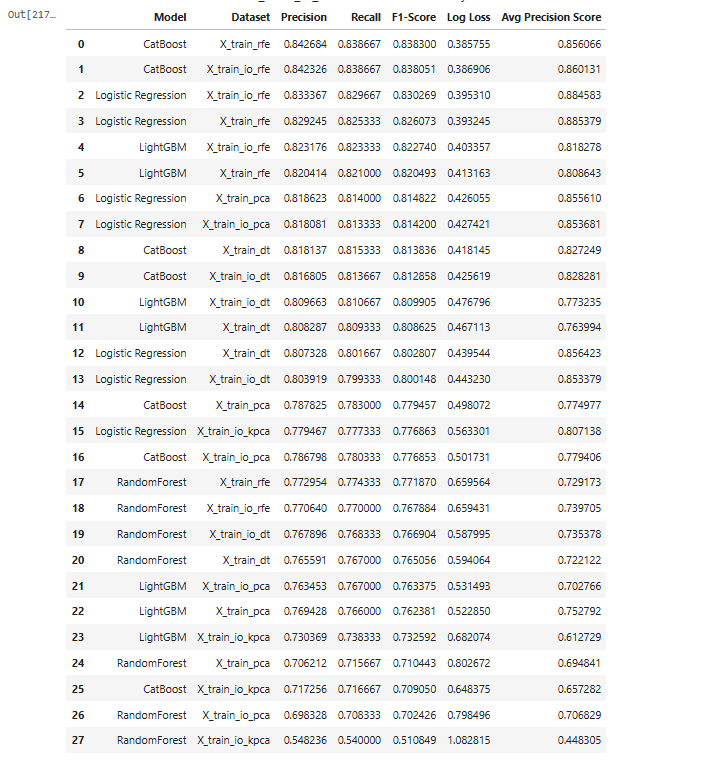

In [85]:
columns = ["Model", "Dataset", "Precision", "Recall", "F1-Score", "Log Loss", "Avg Precision Score"]
results_df = pd.DataFrame(list_of_lists, columns=columns)
results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

,Model,Dataset,Precision,Recall,F1-Score,Log Loss,Avg Precision Score
0,CatBoost,X_train_io_rfe,0.825133,0.822333,0.821798,0.406541,0.897435
1,LightGBM,X_train_rfe,0.821974,0.821333,0.820918,0.427000,0.886086
2,CatBoost,X_train_rfe,0.824177,0.821333,0.820777,0.406659,0.895471
3,Logistic Regression,X_train_rfe,0.824009,0.819000,0.819752,0.408933,0.903922
4,CatBoost,X_train_io,0.823634,0.819000,0.817816,0.415791,0.892282
5,CatBoost,X_train,0.822453,0.818333,0.817781,0.415444,0.892324
6,Logistic Regression,X_train,0.822049,0.816667,0.817477,0.411833,0.898295
7,Logistic Regression,X_train_io,0.820640,0.815333,0.816074,0.415635,0.897466
8,Logistic Regression,X_train_io_rfe,0.820302,0.814333,0.815500,0.417140,0.901264
9,LightGBM,X_train_io_rfe,0.814787,0.814000,0.813670,0.439956,0.876653
